# ShopFlow E-Commerce — Q1 2025 Sales Analysis
**Author:** Dave Hill  
**Date:** March 2026  
**Dataset:** `shopflow_raw_orders_q1_2025.csv` — ~9,700 rows of order-level data  

---

### Objective
Analyse ShopFlow's Q1 2025 (Jan–Mar) sales performance to understand:
- Revenue trends across months and channels
- Top-performing product categories and SKUs
- New vs. returning customer behaviour
- Return rate patterns by category



## 0. Setup

In [1]:
#Load in required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# Notebook display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#fafafa',
    'axes.facecolor': '#fafafa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'sans-serif',
})

#select colors for graphs
COLORS = ['#4f86c6', '#f4a261', '#2a9d8f', '#e76f51', '#a8dadc']

print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1. Load Raw Data

In [2]:
# Load in raw orders
df_raw = pd.read_csv('./shopflow_raw_orders_q1_2025.csv')
print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

# Preview Data
df_raw.head()

Shape: 9,697 rows × 14 columns


,order_id,order_date,customer_id,customer_type,product_name,category,unit_price,quantity,revenue,channel,device,region,returned,return_reason
0,ORD-1667,2025-01-07,CUST-2338,New,Oversized Linen Tee,Apparel,24.00,1,24.00,Organic Search,Mobile,Northeast,No,NaN
1,ORD-2293,2025-01-13,CUST-1051,New,French Press Mug,Home & Kitchen,20.00,1,20.00,Referral,Desktop,Midwest,No,NaN
2,ORD-1286,2025-01-03,CUST-2023,New,Bamboo Cutting Board Set,Home & Kitchen,16.00,1,16.00,Organic Search,Desktop,West,No,NaN
3,ORD-5348,2025-02-12,CUST-2037,New,Stoneware Mug Set,Home & Kitchen,34.00,1,34.00,Direct,Mobile,Northeast,No,NaN
4,ORD-3663,2025-01-27,CUST-2036,New,Canvas Weekender Bag,Accessories,59.99,2,119.98,Paid Social,Desktop,Southwest,No,NaN


In [3]:
# Column types at a glance
df_raw.dtypes

order_id          object
order_date        object
customer_id       object
customer_type     object
product_name      object
category          object
unit_price       float64
quantity           int64
revenue          float64
channel           object
device            object
region            object
returned          object
return_reason     object
dtype: object

---
## 2. Data Quality Assessment

Before any analysis we need to understand what's broken in the raw data. Always do this first — never assume clean data.

In [6]:
# Get nubmer of Null counts
nulls = df_raw.isnull().sum()
nulls[nulls > 0]

customer_id         1
category            1
revenue             1
region              1
return_reason    8638
dtype: int64

In [7]:
# Get number of Duplicate order IDs
dupes = df_raw[df_raw.duplicated(subset=['order_id'], keep=False)]
print(f'Rows with duplicate order_id: {len(dupes)}')
dupes[['order_id', 'order_date', 'customer_id', 'product_name']]

Rows with duplicate order_id: 6


,order_id,order_date,customer_id,product_name
3385,ORD-9999,2025-03-25,CUST-0698,Linen Joggers - Slate
5232,ORD-8888,2025-03-15,CUST-2009,Leather Card Wallet
9693,ORD-DUPE,2025-01-15,CUST-0042,Canvas Weekender Bag
9694,ORD-DUPE,2025-01-15,CUST-0042,Canvas Weekender Bag
9695,ORD-9999,2025-02-30,NaN,Unknown Item
9696,ORD-8888,2025-03-10,CUST-0101,Merino Crew Sweater


In [9]:
# Get number of Invalid dates
df_raw['date_parsed'] = pd.to_datetime(df_raw['order_date'], errors='coerce')
bad_dates = df_raw[df_raw['date_parsed'].isnull()]
print(f'Unparseable dates: {len(bad_dates)}')

bad_dates[['order_id', 'order_date']]

Unparseable dates: 1


,order_id,order_date
9695,ORD-9999,2025-02-30


**Summary of issues found:**
- 1 duplicate `order_id` (ORD-DUPE appears twice)
- 1 row with an impossible date (`2025-02-30`)
- 1 row with missing `revenue`
- 1 row with negative `unit_price` and zero `quantity`
- 1 row with `returned = 'Maybe'` (invalid value)
- Some rows with empty `customer_id` and `category`

These are exactly the kinds of issues you'd find in a real raw export. We'll clean them all in the next step.

---
## 3. Data Cleaning

In [10]:
df = df_raw.copy()
start_count = len(df)

# Drop duplicate order_ids
df = df.drop_duplicates(subset=['order_id'], keep='first')

# Drop rows with invalid dates
df = df[df['date_parsed'].notna()]

# Drop rows with bad numeric values
df = df[(df['revenue'] > 0) & (df['quantity'] > 0) & (df['unit_price'] > 0)]

# Drop rows with missing key fields
df = df[df['customer_id'].notna() & (df['customer_id'] != '')]
df = df[df['category'].notna() & (df['category'] != '')]

# Keep only valid 'returned' values
df = df[df['returned'].isin(['Yes', 'No'])]

print(f'Rows removed : {start_count - len(df)}')
print(f'Clean rows   : {len(df):,}')

Rows removed : 3
Clean rows   : 9,694


In [11]:
# Feature engineering 
# Added useful columns from the date
df['order_date']  = df['date_parsed']
df['month']       = df['order_date'].dt.month
df['month_name']  = df['order_date'].dt.strftime('%B')
df['week']        = df['order_date'].dt.isocalendar().week.astype(int)
df['weekday']     = df['order_date'].dt.day_name()
df['is_returned'] = df['returned'] == 'Yes'

df = df.drop(columns=['date_parsed'])
df.head(3)

,order_id,order_date,customer_id,customer_type,product_name,category,unit_price,quantity,revenue,channel,device,region,returned,return_reason,month,month_name,week,weekday,is_returned
0,ORD-1667,2025-01-07,CUST-2338,New,Oversized Linen Tee,Apparel,24.00,1,24.00,Organic Search,Mobile,Northeast,No,NaN,1,January,2,Tuesday,False
1,ORD-2293,2025-01-13,CUST-1051,New,French Press Mug,Home & Kitchen,20.00,1,20.00,Referral,Desktop,Midwest,No,NaN,1,January,3,Monday,False
2,ORD-1286,2025-01-03,CUST-2023,New,Bamboo Cutting Board Set,Home & Kitchen,16.00,1,16.00,Organic Search,Desktop,West,No,NaN,1,January,1,Friday,False


In [12]:
# Save clean file for re-use
df.to_csv('shopflow_clean_q1_2025.csv', index=False)
print('Saved: shopflow_clean_q1_2025.csv ✓')

Saved: shopflow_clean_q1_2025.csv ✓


---
## 4. Exploratory Data Analysis (EDA)

### 4a. Monthly Revenue

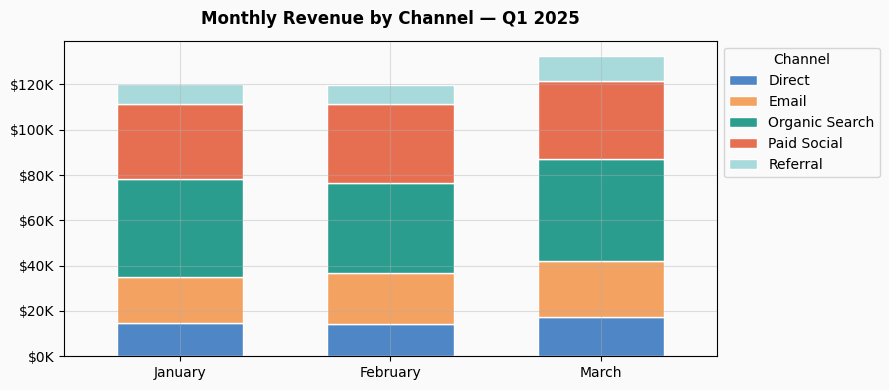

month_name
January     $120,262
February    $119,770
March       $132,661
Name: revenue, dtype: object


In [13]:
# Set month order 
month_order = ['January', 'February', 'March']

# Reorder dataframe so its easier to plot multiple columns for each month 
monthly = df.groupby(['month_name', 'channel'])['revenue'].sum().unstack().reindex(month_order)

#make bar graph showing revenue by month
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(kind='bar', stacked=True, ax=ax, color=COLORS, width=0.6, edgecolor='white')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Monthly Revenue by Channel — Q1 2025', fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_xticklabels(month_order, rotation=0)
ax.legend(title='Channel', bbox_to_anchor=(1, 1), loc='upper left', framealpha=0.8)
plt.tight_layout()
plt.show()

print(df.groupby('month_name')['revenue'].sum().reindex(month_order).apply(lambda x: f'${x:,.0f}'))

### 4b. Category Performance

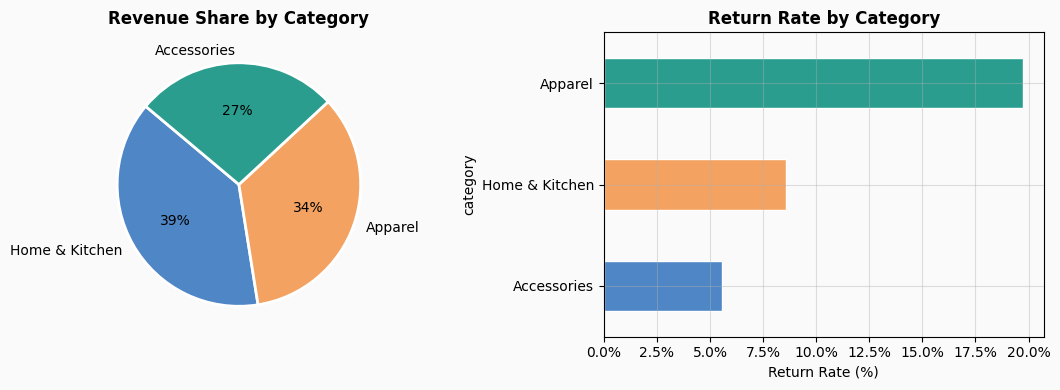

,orders,revenue,aov,return_rate_pct,rev_share
category,,,,,
Home & Kitchen,4992,"143,940.00",28.83,8.59,0.39
Apparel,2599,"128,177.00",49.32,19.74,0.34
Accessories,2103,"100,576.02",47.83,5.56,0.27


In [14]:
cat_summary = df.groupby('category').agg(
    orders=('order_id', 'count'),
    revenue=('revenue', 'sum'),
    aov=('revenue', 'mean'),
    return_rate=('is_returned', 'mean')
).sort_values('revenue', ascending=False)

cat_summary['rev_share'] = cat_summary['revenue'] / cat_summary['revenue'].sum()
cat_summary['return_rate_pct'] = cat_summary['return_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Revenue share pie
axes[0].pie(
    cat_summary['revenue'],
    labels=cat_summary.index,
    autopct='%1.0f%%',
    colors=COLORS[:len(cat_summary)],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Revenue Share by Category', fontweight='bold')

# Return rate bar
cat_summary['return_rate_pct'].sort_values().plot(
    kind='barh', ax=axes[1], color=COLORS[:len(cat_summary)], edgecolor='white'
)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Return Rate by Category', fontweight='bold')
axes[1].set_xlabel('Return Rate (%)')
plt.tight_layout()
plt.show()

cat_summary[['orders', 'revenue', 'aov', 'return_rate_pct', 'rev_share']]

### 4c. New vs. Returning Customers

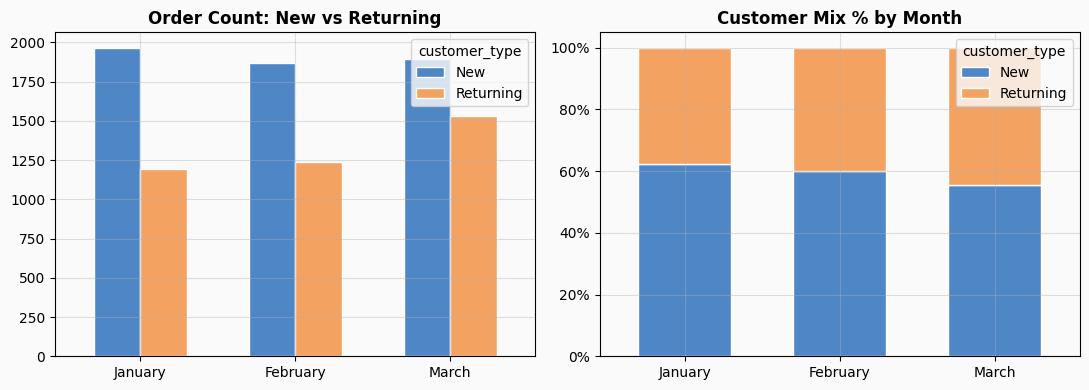

Average Order Value by Customer Type:
customer_type
New          $38.72
Returning    $38.05
Name: revenue, dtype: object


In [15]:
cust_mix = df.groupby(['month_name', 'customer_type'])['order_id'].count().unstack().reindex(month_order)
cust_pct = cust_mix.div(cust_mix.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cust_mix.plot(kind='bar', ax=axes[0], color=[COLORS[0], COLORS[1]], width=0.6, edgecolor='white')
axes[0].set_title('Order Count: New vs Returning', fontweight='bold')
axes[0].set_xticklabels(month_order, rotation=0)
axes[0].set_xlabel('')

cust_pct.plot(kind='bar', stacked=True, ax=axes[1], color=[COLORS[0], COLORS[1]], width=0.6, edgecolor='white')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Customer Mix % by Month', fontweight='bold')
axes[1].set_xticklabels(month_order, rotation=0)
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

# AOV comparison
aov_by_type = df.groupby('customer_type')['revenue'].mean()
print('Average Order Value by Customer Type:')
print(aov_by_type.apply(lambda x: f'${x:.2f}'))

### 4d. Device & Channel Analysis

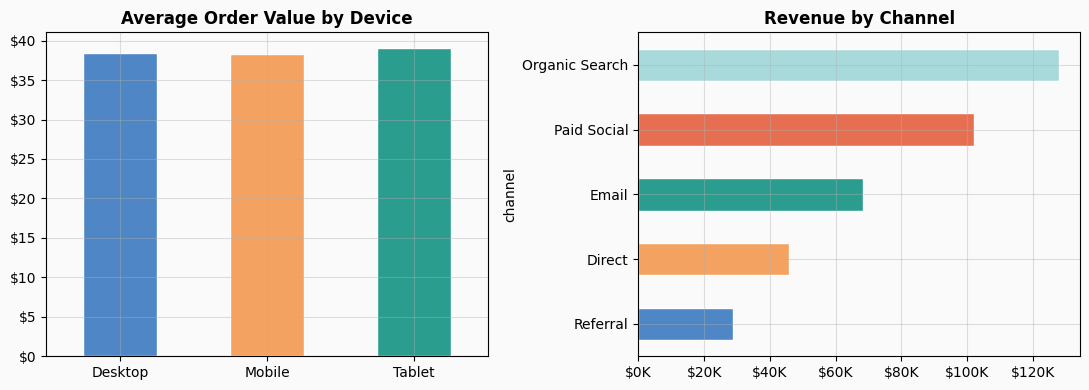

In [16]:
device_aov = df.groupby('device')['revenue'].agg(['mean', 'count']).rename(columns={'mean': 'aov', 'count': 'orders'})
channel_rev = df.groupby('channel')['revenue'].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

device_aov['aov'].plot(kind='bar', ax=axes[0], color=COLORS[:3], edgecolor='white', width=0.5)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}'))
axes[0].set_title('Average Order Value by Device', fontweight='bold')
axes[0].set_xticklabels(device_aov.index, rotation=0)
axes[0].set_xlabel('')

channel_rev.plot(kind='barh', ax=axes[1], color=COLORS[:len(channel_rev)], edgecolor='white')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].set_title('Revenue by Channel', fontweight='bold')
plt.tight_layout()
plt.show()

### 4e. Top Products

In [17]:
top_products = df.groupby(['product_name', 'category']).agg(
    units_sold=('quantity', 'sum'),
    revenue=('revenue', 'sum'),
    return_rate=('is_returned', 'mean')
).sort_values('revenue', ascending=False).head(8)

top_products['return_rate'] = (top_products['return_rate'] * 100).round(1).astype(str) + '%'
top_products

,,units_sold,revenue,return_rate
product_name,category,,,
Canvas Weekender Bag,Accessories,898,"53,871.02",5.3%
Merino Crew Sweater,Apparel,709,"48,921.00",20.1%
Ceramic Pour-Over Kit,Home & Kitchen,1668,"41,700.00",9.8%
Linen Joggers - Slate,Apparel,1265,"40,480.00",19.1%
Bamboo Cutting Board Set,Home & Kitchen,2250,"36,000.00",8.1%
Leather Card Wallet,Accessories,1411,"35,275.00",6.0%
French Press Mug,Home & Kitchen,1673,"33,460.00",8.9%
Oversized Linen Tee,Apparel,1095,"26,280.00",21.7%


### 4f. Weekly Order Volume Trend

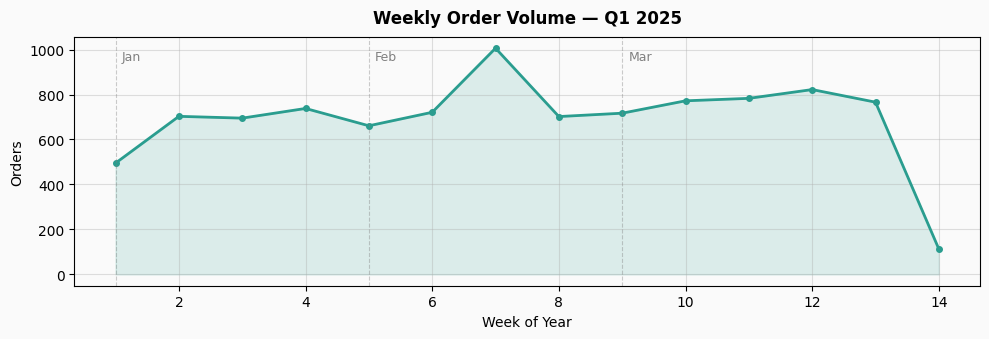

In [18]:
weekly = df.groupby('week')['order_id'].count()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(weekly.index, weekly.values, color=COLORS[2], linewidth=2, marker='o', markersize=4)
ax.fill_between(weekly.index, weekly.values, alpha=0.15, color=COLORS[2])
ax.set_title('Weekly Order Volume — Q1 2025', fontweight='bold', pad=10)
ax.set_xlabel('Week of Year')
ax.set_ylabel('Orders')
# Add month labels
for week, label in [(1, 'Jan'), (5, 'Feb'), (9, 'Mar')]:
    ax.axvline(x=week, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
    ax.text(week + 0.1, weekly.max() * 0.95, label, fontsize=9, color='gray')
plt.tight_layout()
plt.show()

---
## 5. Key Metrics Summary

In [20]:
metrics = {
    'Total Revenue'      : f"${df['revenue'].sum():,.2f}",
    'Total Orders'       : f"{df['order_id'].nunique():,}",
    'Avg Order Value'    : f"${df['revenue'].mean():,.2f}",
    'Return Rate'        : f"{df['is_returned'].mean()*100:.1f}%",
    'Unique Customers'   : f"{df['customer_id'].nunique():,}",
    'Best Month (Rev)'   : df.groupby('month_name')['revenue'].sum().idxmax(),
    'Top Category'       : df.groupby('category')['revenue'].sum().idxmax(),
    'Top Product'        : df.groupby('product_name')['revenue'].sum().idxmax(),
}

pd.Series(metrics).rename('Value').to_frame()

,Value
Total Revenue,"$372,693.02"
Total Orders,"9,694"
Avg Order Value,$38.45
Return Rate,10.9%
Unique Customers,"1,923"
Best Month (Rev),March
Top Category,Home & Kitchen
Top Product,Canvas Weekender Bag


---
## 6. Key Findings & Observations

Write your own notes here after working through the analysis. This is the section you'd translate into the written report.

**My observations:**

1. **Revenue grew each month** — March was strongest, suggesting the Q1 trend is positive heading into Q2.

2. **Home & Kitchen is the top category by revenue share** — the Pour-Over Kit and Cutting Board Set drove volume, but lower AOV than Accessories.

3. **Apparel has a significantly higher return rate (~20%)** — the Linen Joggers and Oversized Tee are the main culprits. Worth investigating sizing feedback.

4. **Returning customer share is growing** — from 38% in January to 44% in March. This is a positive signal for LTV.

5. **Desktop AOV is higher than mobile** — but mobile drives the majority of orders. Conversion optimisation on mobile is the biggest lever.

6. **Organic Search is the top revenue channel** — email is punching above its weight given lower spend.

> **TODO:** Get CAC data from the marketing team to understand which channels are actually most efficient on a per-dollar basis.

---
*End of analysis notebook. Next step: compile findings into the final stakeholder report.*